In [ ]:
!pip install opencv-python
!pip install tqdm


In [1]:
#THIS IS HISTOGRAM 
# 1. Import required libraries

import cv2
import os
import csv
import numpy as np
from tqdm import tqdm


In [3]:
# 2. ColorDescriptor class for RGB histogram
class ColorDescriptor:
    def __init__(self, bins=(8, 8, 8)):
        self.bins = bins

    def describe(self, image):
        hist = cv2.calcHist([image], [0, 1, 2], None, self.bins, [0, 180, 0, 256, 0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        return hist.tolist()
        
# 3. Feature extraction and indexing
def extract_features(dataset_path, output_csv):
    cd = ColorDescriptor()
    with open(output_csv, "w", newline='') as f:
        writer = csv.writer(f)
        for image_name in tqdm(os.listdir(dataset_path), desc=f"Indexing {output_csv}"):
            image_path = os.path.join(dataset_path, image_name)
            image = cv2.imread(image_path)
            if image is None:
                continue
            features = cd.describe(image)
            writer.writerow([image_path] + features)
            
# 4. Chi-square distance
def chi2_distance(histA, histB, eps=1e-10):
    return 0.5 * np.sum([((a - b) ** 2) / (a + b + eps) for a, b in zip(histA, histB)])
    
# 5. Find best match for each Messidor image
def match_images(messidor_csv, ptrbynum_csv, output_file):
    matches = []
    
    # Load painters dataset into memory
    painters_data = []
    with open(ptrbynum_csv, 'r') as f:
        reader = csv.reader(f)
        for row in reader:
            painters_data.append((row[0], [float(x) for x in row[1:]]))
    
    with open(messidor_csv, 'r') as f:
        reader = csv.reader(f)
        for row in tqdm(reader, desc="Matching Messidor to Painters"):
            messidor_img = row[0]
            messidor_feat = [float(x) for x in row[1:]]
            
            best_score = float('inf')
            best_match = None
            
            for painter_img, painter_feat in painters_data:
                d = chi2_distance(messidor_feat, painter_feat)
                if d < best_score:
                    best_score = d
                    best_match = painter_img
                    
            matches.append((messidor_img, best_match))
    
    # Save matches
    with open(output_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Messidor Image', 'Painter Match'])
        writer.writerows(matches)



In [4]:
# 6. Run the full pipeline
messidor_dir = './messidor'
ptrbynum_dir = './painters_by_numbers'

extract_features(messidor_dir, 'messidor_histogram.csv')
extract_features(ptrbynum_dir, 'ptrbynum_histogram.csv')
match_images('messidor_histogram.csv', 'ptrbynum_histogram.csv', 'matches.csv')


Indexing ptrbynum_histogram.csv: 100%|██████████████████████████████████████████████| 8476/8476 [04:03<00:00, 34.77it/s]
Matching Messidor to Painters: 382it [02:35,  2.45it/s]


In [5]:
!pip install pandas


In [6]:
#THIS IS NEURAL STYLE TRANSFER

# 📦 Imports
import os
import cv2 as cv
import numpy as np
import torch
from torch import nn
from torchvision import models, transforms
from torch.optim import LBFGS
from torch.autograd import Variable
import pandas as pd

# 🧠 Constants
IMAGENET_MEAN_255 = [123.675, 116.28, 103.53]
IMAGENET_STD_NEUTRAL = [1, 1, 1]

In [7]:
# 📂 Dataset paths
matches_csv_path = 'matches.csv'
messidor_dir = './messidor'
painters_dir = './painters_by_numbers'
output_img_dir = './nst_output'

# 🔧 Utility Functions

def load_image(img_path, target_shape=None):
    if not os.path.exists(img_path):
        raise Exception(f'Path not found: {img_path}')
    img = cv.imread(img_path)[:, :, ::-1]  # BGR to RGB
    if target_shape is not None:
        if isinstance(target_shape, int) and target_shape != -1:
            h, w = img.shape[:2]
            new_h = target_shape
            new_w = int(w * (new_h / h))
            img = cv.resize(img, (new_w, new_h), interpolation=cv.INTER_CUBIC)
        else:
            img = cv.resize(img, (target_shape[1], target_shape[0]), interpolation=cv.INTER_CUBIC)
    img = img.astype(np.float32) / 255.0
    return img

In [8]:
def prepare_img(img_path, target_shape, device):
    img = load_image(img_path, target_shape=target_shape)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.mul(255)),
        transforms.Normalize(mean=IMAGENET_MEAN_255, std=IMAGENET_STD_NEUTRAL)
    ])
    img = transform(img).to(device).unsqueeze(0)
    return img

def save_image(img_tensor, path):
    img = img_tensor.squeeze().cpu().detach().numpy()
    img = np.moveaxis(img, 0, 2)
    img += np.array(IMAGENET_MEAN_255).reshape((1, 1, 3))
    img = np.clip(img, 0, 255).astype('uint8')
    cv.imwrite(path, img[:, :, ::-1])  # RGB to BGR

def gram_matrix(x, normalize=True):
    (b, ch, h, w) = x.size()
    features = x.view(b, ch, w * h)
    features_t = features.transpose(1, 2)
    gram = features.bmm(features_t)
    if normalize:
        gram /= ch * h * w
    return gram

def total_variation(y):
    return torch.sum(torch.abs(y[:, :, :, :-1] - y[:, :, :, 1:])) + torch.sum(torch.abs(y[:, :, :-1, :] - y[:, :, 1:, :]))


In [9]:
# 🧠 VGG Feature Extractor

class Vgg19(nn.Module):
    def __init__(self, requires_grad=False):
        super(Vgg19, self).__init__()
        vgg_pretrained_features = models.vgg19(weights='VGG19_Weights.DEFAULT').features
        self.slice = nn.ModuleList()
        self.layer_names = []
        count = 0
        for layer in vgg_pretrained_features:
            if isinstance(layer, nn.ReLU):
                layer = nn.ReLU(inplace=False)
            self.slice.append(layer)
            self.layer_names.append(f'layer_{count}')
            count += 1
        if not requires_grad:
            for param in self.parameters():
                param.requires_grad = False
        self.content_feature_maps_index = 21
        self.style_feature_maps_indices = [0, 5, 10, 19, 28]

    def forward(self, x):
        features = []
        for i, layer in enumerate(self.slice):
            x = layer(x)
            if i in self.style_feature_maps_indices or i == self.content_feature_maps_index:
                features.append(x)
        return features

# 🎨 NST Core Logic

def build_loss(model, optimizing_img, targets, content_idx, style_indices, config):
    content_target, style_targets = targets
    features = model(optimizing_img)

    content_pred = features[style_indices.index(content_idx)]
    content_loss = nn.MSELoss()(content_pred.squeeze(), content_target)

    style_loss = 0.0
    for gt, pred in zip(style_targets, [gram_matrix(f) for i, f in enumerate(features) if i in style_indices]):
        style_loss += nn.MSELoss()(gt, pred)

    style_loss /= len(style_targets)
    tv_loss = total_variation(optimizing_img)

    total = config['content_weight'] * content_loss + config['style_weight'] * style_loss + config['tv_weight'] * tv_loss
    return total, content_loss, style_loss, tv_loss

def neural_style_transfer(config):
    content_img_path = os.path.join(config['content_images_dir'], config['content_img_name'])
    style_img_path = os.path.join(config['style_images_dir'], config['style_img_name'])

    out_img_name = f"{os.path.splitext(config['content_img_name'])[0]}_nst.jpg"
    dump_path = config['output_img_dir']
    os.makedirs(dump_path, exist_ok=True)

    # Assuming final_output_img is the result from NST
    # final_output_img = ...  # <-- Your NST output
    # final_output_img.save(os.path.join(dump_path, out_img_name))
    print(f"✅ Saved NST image to {os.path.join(dump_path, out_img_name)}")


    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    content_img = prepare_img(content_img_path, config['height'], device)
    style_img = prepare_img(style_img_path, config['height'], device)
    init_img = content_img.clone()

    model = Vgg19().to(device).eval()

    # Extract features
    content_and_style_feats = model(content_img)
    style_feats = model(style_img)

    # Last feature is content, others are style
    content_target = content_and_style_feats[-1].squeeze()
    style_targets = [gram_matrix(feat) for feat in style_feats[:-1]]

    targets = (content_target, style_targets)
    optimizing_img = Variable(init_img.clone(), requires_grad=True)
    optimizer = LBFGS([optimizing_img], max_iter=300)

    iteration = [0]
    def closure():
        optimizer.zero_grad()
        feats = model(optimizing_img)
        content_feat = feats[-1]
        style_feats_out = feats[:-1]

        content_loss = nn.MSELoss()(content_feat.squeeze(), content_target)

        style_loss = 0.0
        for gt, pred in zip(style_targets, [gram_matrix(f) for f in style_feats_out]):
            style_loss += nn.MSELoss()(gt, pred)

        style_loss /= len(style_targets)
        tv_loss = total_variation(optimizing_img)

        total = config['content_weight'] * content_loss + config['style_weight'] * style_loss + config['tv_weight'] * tv_loss
        total.backward()

        if iteration[0] % 50 == 0:
            print(f"Iter {iteration[0]} | Total: {total.item():.2f} | Content: {content_loss.item():.2f} | Style: {style_loss.item():.2f} | TV: {tv_loss.item():.2f}")
        iteration[0] += 1
        return total

    optimizer.step(closure)

    final_img_path = os.path.join(dump_path, f"{os.path.splitext(config['content_img_name'])[0]}_nst.jpg")
    save_image(optimizing_img, final_img_path)
    print(f"✅ Saved to: {final_img_path}")


In [10]:
# 🔁 Run NST for all matched pairs

matches = pd.read_csv(matches_csv_path)

for idx, row in matches.iterrows():
    content_img = os.path.basename(row['Messidor Image'])
    style_img = os.path.basename(row['Painter Match'])

    config = {
        'content_img_name': content_img,
        'style_img_name': style_img,
        'height': 400,
        'content_weight': 100000.0,
        'style_weight': 30000.0,
        'tv_weight': 1.0,
        'content_images_dir': messidor_dir,
        'style_images_dir': painters_dir,
        'output_img_dir': output_img_dir,
        'img_format': (4, '.jpg')
    }

    print(f"\n🎨 Transferring style from {style_img} to {content_img}...")
    neural_style_transfer(config)




🎨 Transferring style from 24645.jpg to c1.jpg...
✅ Saved NST image to ./nst_output/c1_nst.jpg
Iter 0 | Total: 17618100224.00 | Content: 0.00 | Style: 587190.00 | TV: 2399570.00
Iter 50 | Total: 797435328.00 | Content: 1967.22 | Style: 19470.40 | TV: 16601348.00
Iter 100 | Total: 464244352.00 | Content: 1360.45 | Style: 10355.96 | TV: 17520288.00
Iter 150 | Total: 359008928.00 | Content: 1109.58 | Style: 7654.16 | TV: 18426648.00
Iter 200 | Total: 306104928.00 | Content: 979.45 | Style: 6301.14 | TV: 19125998.00
Iter 250 | Total: 274945216.00 | Content: 895.56 | Style: 5528.61 | TV: 19530760.00
✅ Saved to: ./nst_output/c1_nst.jpg

🎨 Transferring style from 23994.jpg to c10.jpg...
✅ Saved NST image to ./nst_output/c10_nst.jpg
Iter 0 | Total: 3923289344.00 | Content: 0.00 | Style: 130693.41 | TV: 2486979.00
Iter 50 | Total: 416688320.00 | Content: 884.59 | Style: 10680.64 | TV: 7810411.00
Iter 100 | Total: 288247296.00 | Content: 638.03 | Style: 7196.85 | TV: 8538594.00
Iter 150 | Total:

In [11]:
import os
import random
import numpy as np
from PIL import Image
from torchvision import datasets
from torch.utils.data import Dataset

# === UTILS ===

class Utils:

    @staticmethod
    def load_fractal_images(fractal_img_dir):
        fractal_img_paths = [os.path.join(fractal_img_dir, fname)
                             for fname in os.listdir(fractal_img_dir)
                             if fname.endswith(('.png', '.jpg', '.jpeg'))]
        return [Image.open(path).convert('RGB').resize((256, 256)) for path in fractal_img_paths]

    @staticmethod
    def blend_images_with_resize(base_img, overlay_img, alpha=0.05):
        overlay_img_resized = overlay_img.resize(base_img.size)
        base_array = np.array(base_img, dtype=np.float32)
        overlay_array = np.array(overlay_img_resized, dtype=np.float32)
        assert base_array.shape == overlay_array.shape and len(base_array.shape) == 3
        blended_array = (1 - alpha) * base_array + alpha * overlay_array
        blended_array = np.clip(blended_array, 0, 255).astype(np.uint8)
        return Image.fromarray(blended_array)

    @staticmethod
    def combine_images(original_img, augmented_img, blend_width=20):
        width, height = original_img.size
        combine_choice = random.choice(['horizontal', 'vertical'])

        if combine_choice == 'vertical':
            mask = np.linspace(0, 1, blend_width).reshape(-1, 1)
            mask = np.tile(mask, (1, width))
            mask = np.vstack([
                np.zeros((height // 2 - blend_width // 2, width)),
                mask,
                np.ones((height // 2 - blend_width // 2 + blend_width % 2, width))
            ])
            mask = np.tile(mask[:, :, np.newaxis], (1, 1, 3))
        else:
            mask = np.linspace(0, 1, blend_width).reshape(1, -1)
            mask = np.tile(mask, (height, 1))
            mask = np.hstack([
                np.zeros((height, width // 2 - blend_width // 2)),
                mask,
                np.ones((height, width // 2 - blend_width // 2 + blend_width % 2))
            ])
            mask = np.tile(mask[:, :, np.newaxis], (1, 1, 3))

        original_array = np.array(original_img, dtype=np.float32) / 255.0
        augmented_array = np.array(augmented_img, dtype=np.float32) / 255.0

        blended_array = (1 - mask) * original_array + mask * augmented_array
        blended_array = np.clip(blended_array * 255, 0, 255).astype(np.uint8)

        return Image.fromarray(blended_array)

    @staticmethod
    def is_black_image(image):
        histogram = image.convert("L").histogram()
        return histogram[-1] > 0.9 * image.size[0] * image.size[1] and max(histogram[:-1]) < 0.1 * image.size[0] * image.size[1]



In [12]:
class DiffuseMix(Dataset):
    def __init__(self, messidor_dir, stylized_dir, fractal_imgs):
        self.messidor_dir = messidor_dir
        self.stylized_dir = stylized_dir
        self.fractal_imgs = fractal_imgs
        self.utils = Utils()
        self.image_pairs = self.match_image_pairs()
        self.augmented_images = self.generate_augmented_images()

    def match_image_pairs(self):
        messidor_images = [f for f in os.listdir(self.messidor_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        stylized_images = [f for f in os.listdir(self.stylized_dir) if f.endswith(('_nst.jpg'))]

        pairs = []
        for s_img in stylized_images:
            base_name = s_img.replace("_nst.jpg", ".jpg")
            if base_name in messidor_images:
                pairs.append((base_name, s_img))
            else:
                print(f"❌ No match found for: {s_img}")
        return pairs

    def generate_augmented_images(self):
        base_directory = './result'
        dirs = {
            'original_resized': os.path.join(base_directory, 'original_resized'),
            'stylized': os.path.join(base_directory, 'stylized'),
            'concatenated': os.path.join(base_directory, 'concatenated'),
            'blended': os.path.join(base_directory, 'blended'),
            'fractal': os.path.join(base_directory, 'fractal')
        }

        for dir_path in dirs.values():
            os.makedirs(dir_path, exist_ok=True)

        augmented_data = []

        print("\n🚀 Starting augmentation...\n")

        for base_name, style_name in self.image_pairs:
            base_filename = os.path.splitext(base_name)[0]

            original_img_path = os.path.join(self.messidor_dir, base_name)
            stylized_img_path = os.path.join(self.stylized_dir, style_name)

            original_img = Image.open(original_img_path).convert('RGB').resize((256, 256))
            stylized_img = Image.open(stylized_img_path).convert('RGB').resize((256, 256))

            if self.utils.is_black_image(stylized_img):
                print(f"⚠️ Skipping black stylized image: {stylized_img_path}")
                continue

            # Save original
            original_img.save(os.path.join(dirs['original_resized'], base_name))

            # Save stylized
            stylized_img.save(os.path.join(dirs['stylized'], style_name))

            # Concatenate
            concatenated = self.utils.combine_images(original_img, stylized_img)
            concat_path = os.path.join(dirs['concatenated'], f"{base_filename}_concat.jpg")
            concatenated.save(concat_path)

            # Fractal
            fractal_img = random.choice(self.fractal_imgs)
            fractal_path = os.path.join(dirs['fractal'], f"{base_filename}_fractal.jpg")
            fractal_img.save(fractal_path)

            # Blend
            blended = self.utils.blend_images_with_resize(concatenated, fractal_img)
            blended_path = os.path.join(dirs['blended'], f"{base_filename}_blended.jpg")
            blended.save(blended_path)

            augmented_data.append((blended, base_filename))

        print("\n✅ Augmentation complete!\n")
        return augmented_data

    def __len__(self):
        return len(self.augmented_images)

    def __getitem__(self, idx):
        return self.augmented_images[idx]


In [13]:
# Paths
messidor_path = './messidor'           
stylized_path = './nst_output'            
fractal_dir = './fractal_images'         

# Load
fractal_imgs = Utils.load_fractal_images(fractal_dir)

# No class structure needed now
diffusemix_dataset = DiffuseMix(
    messidor_dir=messidor_path,
    stylized_dir=stylized_path,
    fractal_imgs=fractal_imgs
)

# Save augmented images to disk
os.makedirs("augmented_images", exist_ok=True)
for idx, (image, name) in enumerate(diffusemix_dataset):
    path = f"augmented_images/{name}.jpg"
    image.save(path)
    print(f"✅ Saved: {path}")



🚀 Starting augmentation...


✅ Augmentation complete!

✅ Saved: augmented_images/c100.jpg
✅ Saved: augmented_images/c101.jpg
✅ Saved: augmented_images/c102.jpg
✅ Saved: augmented_images/c103.jpg
✅ Saved: augmented_images/c104.jpg
✅ Saved: augmented_images/c105.jpg
✅ Saved: augmented_images/c106.jpg
✅ Saved: augmented_images/c107.jpg
✅ Saved: augmented_images/c108.jpg
✅ Saved: augmented_images/c109.jpg
✅ Saved: augmented_images/c10.jpg
✅ Saved: augmented_images/c110.jpg
✅ Saved: augmented_images/c111.jpg
✅ Saved: augmented_images/c112.jpg
✅ Saved: augmented_images/c113.jpg
✅ Saved: augmented_images/c114.jpg
✅ Saved: augmented_images/c115.jpg
✅ Saved: augmented_images/c116.jpg
✅ Saved: augmented_images/c117.jpg
✅ Saved: augmented_images/c118.jpg
✅ Saved: augmented_images/c119.jpg
✅ Saved: augmented_images/c11.jpg
✅ Saved: augmented_images/c120.jpg
✅ Saved: augmented_images/c121.jpg
✅ Saved: augmented_images/c122.jpg
✅ Saved: augmented_images/c123.jpg
✅ Saved: augmented_images/c124.jpg
✅

✅ Saved: augmented_images/c338.jpg
✅ Saved: augmented_images/c339.jpg
✅ Saved: augmented_images/c33.jpg
✅ Saved: augmented_images/c340.jpg
✅ Saved: augmented_images/c341.jpg
✅ Saved: augmented_images/c342.jpg
✅ Saved: augmented_images/c343.jpg
✅ Saved: augmented_images/c344.jpg
✅ Saved: augmented_images/c345.jpg
✅ Saved: augmented_images/c346.jpg
✅ Saved: augmented_images/c347.jpg
✅ Saved: augmented_images/c348.jpg
✅ Saved: augmented_images/c349.jpg
✅ Saved: augmented_images/c34.jpg
✅ Saved: augmented_images/c350.jpg
✅ Saved: augmented_images/c351.jpg
✅ Saved: augmented_images/c352.jpg
✅ Saved: augmented_images/c353.jpg
✅ Saved: augmented_images/c354.jpg
✅ Saved: augmented_images/c355.jpg
✅ Saved: augmented_images/c356.jpg
✅ Saved: augmented_images/c357.jpg
✅ Saved: augmented_images/c358.jpg
✅ Saved: augmented_images/c359.jpg
✅ Saved: augmented_images/c35.jpg
✅ Saved: augmented_images/c360.jpg
✅ Saved: augmented_images/c361.jpg
✅ Saved: augmented_images/c362.jpg
✅ Saved: augmented_imag

In [1]:
!pip install torch torchvision --quiet

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())


2.6.0+cu124
True


In [2]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from torch import nn, optim
from torchvision.models import resnet18
import numpy as np

# Custom Dataset for Triplet training
class TripletDataset(Dataset):
    def __init__(self, positive_dir, anchor_dir, negative_dir, transform=None):
        self.positive_dir = positive_dir
        self.anchor_dir = anchor_dir
        self.negative_dir = negative_dir
        self.transform = transform
        
        # Load the filenames of the images
        self.positive_images = [f for f in os.listdir(positive_dir) if f.endswith('_blended.jpg')]
        self.anchor_images = [f.replace('_blended', '') for f in self.positive_images]  # Matching anchor names
        self.negative_images = [f for f in os.listdir(negative_dir) if f.endswith('.png')]

    def __len__(self):
        return len(self.positive_images)

    def __getitem__(self, idx):
        positive_img_name = self.positive_images[idx]
        anchor_img_name = self.anchor_images[idx]

        # Construct full image paths
        positive_img_path = os.path.join(self.positive_dir, positive_img_name)
        anchor_img_path = os.path.join(self.anchor_dir, anchor_img_name)
        negative_img_name = np.random.choice(self.negative_images)
        negative_img_path = os.path.join(self.negative_dir, negative_img_name)

        # Open images using PIL
        positive_image = Image.open(positive_img_path)
        anchor_image = Image.open(anchor_img_path)
        negative_image = Image.open(negative_img_path)

        # Apply transformation if any
        if self.transform:
            positive_image = self.transform(positive_image)
            anchor_image = self.transform(anchor_image)
            negative_image = self.transform(negative_image)

        return anchor_image, positive_image, negative_image

# Transform to apply to images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [3]:
# Initialize Dataset and DataLoader
positive_dir = './result/blended'
anchor_dir = './messidor'
negative_dir = './negative_images'

dataset = TripletDataset(positive_dir, anchor_dir, negative_dir, transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Define the embedding network (ResNet as an example)
class EmbeddingNet(nn.Module):
    def __init__(self):
        super(EmbeddingNet, self).__init__()
        self.resnet = resnet18(pretrained=True)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, 128)  # Output size 128 for embedding

    def forward(self, x):
        return self.resnet(x)

# Define Triplet Loss
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_distance = torch.norm(anchor - positive, p=2, dim=1)
        neg_distance = torch.norm(anchor - negative, p=2, dim=1)
        loss = torch.clamp(pos_distance - neg_distance + self.margin, min=0.0)
        return loss.mean()

In [5]:
!nvidia-smi


Wed Feb 18 17:32:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 573.71                 Driver Version: 573.71         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A3000 Laptop GPU  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   55C    P5             23W /   35W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124 --force-reinstall --quiet


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
s3fs 2025.10.0 requires fsspec==2025.10.0, but you have fsspec 2025.12.0 which is incompatible.
sip 6.12.0 requires setuptools>=75.8.1, but you have setuptools 70.2.0 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.8 which is incompatible.


In [5]:
# Model, loss, optimizer
model = EmbeddingNet().cuda()
loss_fn = TripletLoss(margin=1.0)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop
def train(model, dataloader, loss_fn, optimizer, n_epochs=10):
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0
        for batch_idx, (anchor, positive, negative) in enumerate(dataloader):
            # Move data to GPU
            anchor, positive, negative = anchor.cuda(), positive.cuda(), negative.cuda()

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            anchor_embedding = model(anchor)
            positive_embedding = model(positive)
            negative_embedding = model(negative)

            # Compute loss
            loss = loss_fn(anchor_embedding, positive_embedding, negative_embedding)

            # Backpropagation
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            if batch_idx % 10 == 0:
                print(f'Epoch [{epoch+1}/{n_epochs}], Step [{batch_idx+1}/{len(dataloader)}], Loss: {loss.item():.4f}')
        
        print(f'Epoch [{epoch+1}/{n_epochs}], Average Loss: {total_loss/len(dataloader):.4f}')

# Start training
train(model, dataloader, loss_fn, optimizer, n_epochs=25)

Epoch [1/25], Step [1/12], Loss: 0.2772
Epoch [1/25], Step [11/12], Loss: 0.1199
Epoch [1/25], Average Loss: 0.1111
Epoch [2/25], Step [1/12], Loss: 0.0158
Epoch [2/25], Step [11/12], Loss: 0.0000
Epoch [2/25], Average Loss: 0.0099
Epoch [3/25], Step [1/12], Loss: 0.0000
Epoch [3/25], Step [11/12], Loss: 0.0042
Epoch [3/25], Average Loss: 0.0032
Epoch [4/25], Step [1/12], Loss: 0.0000
Epoch [4/25], Step [11/12], Loss: 0.0011
Epoch [4/25], Average Loss: 0.0046
Epoch [5/25], Step [1/12], Loss: 0.0258
Epoch [5/25], Step [11/12], Loss: 0.0116
Epoch [5/25], Average Loss: 0.0043
Epoch [6/25], Step [1/12], Loss: 0.0000
Epoch [6/25], Step [11/12], Loss: 0.0000
Epoch [6/25], Average Loss: 0.0041
Epoch [7/25], Step [1/12], Loss: 0.0000
Epoch [7/25], Step [11/12], Loss: 0.0000
Epoch [7/25], Average Loss: 0.0006
Epoch [8/25], Step [1/12], Loss: 0.0000
Epoch [8/25], Step [11/12], Loss: 0.0006
Epoch [8/25], Average Loss: 0.0010
Epoch [9/25], Step [1/12], Loss: 0.0160
Epoch [9/25], Step [11/12], Loss

Epoch [68/200], Average Loss: 0.0059
Epoch [69/200], Step [1/12], Loss: 0.0000
Epoch [69/200], Step [11/12], Loss: 0.0000
Epoch [69/200], Average Loss: 0.0028
Epoch [70/200], Step [1/12], Loss: 0.0073
Epoch [70/200], Step [11/12], Loss: 0.0000
Epoch [70/200], Average Loss: 0.0006
Epoch [71/200], Step [1/12], Loss: 0.0000
Epoch [71/200], Step [11/12], Loss: 0.0000
Epoch [71/200], Average Loss: 0.0031
Epoch [72/200], Step [1/12], Loss: 0.0000
Epoch [72/200], Step [11/12], Loss: 0.0000
Epoch [72/200], Average Loss: 0.0030
Epoch [73/200], Step [1/12], Loss: 0.0000
Epoch [73/200], Step [11/12], Loss: 0.0000
Epoch [73/200], Average Loss: 0.0052
Epoch [74/200], Step [1/12], Loss: 0.0000
Epoch [74/200], Step [11/12], Loss: 0.0000
Epoch [74/200], Average Loss: 0.0055
Epoch [75/200], Step [1/12], Loss: 0.0138
Epoch [75/200], Step [11/12], Loss: 0.0000
Epoch [75/200], Average Loss: 0.0012
Epoch [76/200], Step [1/12], Loss: 0.0000
Epoch [76/200], Step [11/12], Loss: 0.0000
Epoch [76/200], Average 

Epoch [135/200], Step [1/12], Loss: 0.0000
Epoch [135/200], Step [11/12], Loss: 0.0000
Epoch [135/200], Average Loss: 0.0000
Epoch [136/200], Step [1/12], Loss: 0.0000
Epoch [136/200], Step [11/12], Loss: 0.0000
Epoch [136/200], Average Loss: 0.0021
Epoch [137/200], Step [1/12], Loss: 0.0000
Epoch [137/200], Step [11/12], Loss: 0.0000
Epoch [137/200], Average Loss: 0.0000
Epoch [138/200], Step [1/12], Loss: 0.0000
Epoch [138/200], Step [11/12], Loss: 0.0000
Epoch [138/200], Average Loss: 0.0029
Epoch [139/200], Step [1/12], Loss: 0.0000
Epoch [139/200], Step [11/12], Loss: 0.0000
Epoch [139/200], Average Loss: 0.0005
Epoch [140/200], Step [1/12], Loss: 0.0000
Epoch [140/200], Step [11/12], Loss: 0.0059
Epoch [140/200], Average Loss: 0.0005
Epoch [141/200], Step [1/12], Loss: 0.0000
Epoch [141/200], Step [11/12], Loss: 0.0000
Epoch [141/200], Average Loss: 0.0000
Epoch [142/200], Step [1/12], Loss: 0.0000
Epoch [142/200], Step [11/12], Loss: 0.0000
Epoch [142/200], Average Loss: 0.0000


Epoch [200/200], Average Loss: 0.0000


In [6]:
!pip install matplotlib
!pip install scikit-learn

In [7]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def visualize_embeddings_unsupervised(model, dataloader, n_clusters=2, use_tsne=True):
    model.eval()
    embeddings = []

    with torch.no_grad():
        for anchor, _, _ in dataloader:
            anchor = anchor.cuda()
            output = model(anchor)
            embeddings.append(output.cpu())

    embeddings = torch.cat(embeddings, dim=0).numpy()

    # Clustering with KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Dimensionality Reduction
    if use_tsne:
        reducer = TSNE(n_components=2, random_state=42)
    else:
        reducer = PCA(n_components=2)
    
    reduced_embeddings = reducer.fit_transform(embeddings)

    # Plotting
    plt.figure(figsize=(8, 6))
    for label in range(n_clusters):
        idxs = cluster_labels == label
        plt.scatter(reduced_embeddings[idxs, 0], reduced_embeddings[idxs, 1],
                    label=f'Cluster {label}', alpha=0.7)

    plt.title('Embedding Clusters')
    plt.xlabel('Abstract Feature 1')
    plt.ylabel('Abstract Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return reduced_embeddings, cluster_labels


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


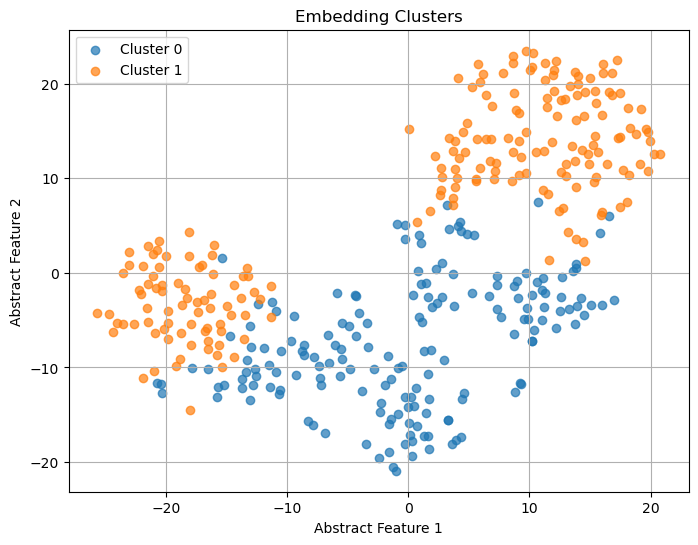

In [8]:
x1, y1 = visualize_embeddings_unsupervised(model, dataloader, n_clusters=2)



In [9]:

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from torch import nn, optim
from torchvision.models import resnet18
import numpy as np

# Custom Dataset for Triplet training
class TripletDataset(Dataset):
    def __init__(self, positive_dir, anchor_dir, negative_dir, transform=None):
        self.positive_dir = positive_dir
        self.anchor_dir = anchor_dir
        self.negative_dir = negative_dir
        self.transform = transform
        
        # Load the filenames of the images
        self.positive_images = [f for f in os.listdir(positive_dir) if f.endswith('_nst.jpg')]
        self.anchor_images = [f.replace('_nst', '') for f in self.positive_images]  # Matching anchor names
        self.negative_images = [f for f in os.listdir(negative_dir) if f.endswith('.png')]

    def __len__(self):
        return len(self.positive_images)

    def __getitem__(self, idx):
        positive_img_name = self.positive_images[idx]
        anchor_img_name = self.anchor_images[idx]

        # Construct full image paths
        positive_img_path = os.path.join(self.positive_dir, positive_img_name)
        anchor_img_path = os.path.join(self.anchor_dir, anchor_img_name)
        negative_img_name = np.random.choice(self.negative_images)
        negative_img_path = os.path.join(self.negative_dir, negative_img_name)

        # Open images using PIL
        positive_image = Image.open(positive_img_path)
        anchor_image = Image.open(anchor_img_path)
        negative_image = Image.open(negative_img_path)

        # Apply transformation if any
        if self.transform:
            positive_image = self.transform(positive_image)
            anchor_image = self.transform(anchor_image)
            negative_image = self.transform(negative_image)

        return anchor_image, positive_image, negative_image

# Transform to apply to images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [51]:
import os

# Initialize Dataset and DataLoader
positive_dir = './nst_output'
anchor_dir = './messidor'
negative_dir = './negative_images'

dataset = TripletDataset(positive_dir, anchor_dir, negative_dir, transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Define the embedding network (ResNet as an example)
class EmbeddingNet(nn.Module):
    def __init__(self):
        super(EmbeddingNet, self).__init__()
        self.resnet = resnet18(pretrained=True)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, 128)  # Output size 128 for embedding

    def forward(self, x):
        return self.resnet(x)

# Define Triplet Loss
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_distance = torch.norm(anchor - positive, p=2, dim=1)
        neg_distance = torch.norm(anchor - negative, p=2, dim=1)
        loss = torch.clamp(pos_distance - neg_distance + self.margin, min=0.0)
        return loss.mean()

In [10]:
# Model, loss, optimizer
model = EmbeddingNet().cuda()
loss_fn = TripletLoss(margin=1.0)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop
def train(model, dataloader, loss_fn, optimizer, n_epochs=10):
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0
        for batch_idx, (anchor, positive, negative) in enumerate(dataloader):
            # Move data to GPU
            anchor, positive, negative = anchor.cuda(), positive.cuda(), negative.cuda()

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            anchor_embedding = model(anchor)
            positive_embedding = model(positive)
            negative_embedding = model(negative)

            # Compute loss
            loss = loss_fn(anchor_embedding, positive_embedding, negative_embedding)

            # Backpropagation
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            if batch_idx % 10 == 0:
                print(f'Epoch [{epoch+1}/{n_epochs}], Step [{batch_idx+1}/{len(dataloader)}], Loss: {loss.item():.4f}')
        
        print(f'Epoch [{epoch+1}/{n_epochs}], Average Loss: {total_loss/len(dataloader):.4f}')

# Start training
train(model, dataloader, loss_fn, optimizer, n_epochs=25)

C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/25], Step [1/12], Loss: 0.3601
Epoch [1/25], Step [11/12], Loss: 0.0000
Epoch [1/25], Average Loss: 0.0986
Epoch [2/25], Step [1/12], Loss: 0.0084
Epoch [2/25], Step [11/12], Loss: 0.0000
Epoch [2/25], Average Loss: 0.0067
Epoch [3/25], Step [1/12], Loss: 0.0024
Epoch [3/25], Step [11/12], Loss: 0.0000
Epoch [3/25], Average Loss: 0.0070
Epoch [4/25], Step [1/12], Loss: 0.0000
Epoch [4/25], Step [11/12], Loss: 0.0106
Epoch [4/25], Average Loss: 0.0035
Epoch [5/25], Step [1/12], Loss: 0.0000
Epoch [5/25], Step [11/12], Loss: 0.0000
Epoch [5/25], Average Loss: 0.0023
Epoch [6/25], Step [1/12], Loss: 0.0000
Epoch [6/25], Step [11/12], Loss: 0.0000
Epoch [6/25], Average Loss: 0.0023
Epoch [7/25], Step [1/12], Loss: 0.0026
Epoch [7/25], Step [11/12], Loss: 0.0000
Epoch [7/25], Average Loss: 0.0013
Epoch [8/25], Step [1/12], Loss: 0.0295
Epoch [8/25], Step [11/12], Loss: 0.0000
Epoch [8/25], Average Loss: 0.0037
Epoch [9/25], Step [1/12], Loss: 0.0000
Epoch [9/25], Step [11/12], Loss

Epoch [68/200], Average Loss: 0.0049
Epoch [69/200], Step [1/12], Loss: 0.0000
Epoch [69/200], Step [11/12], Loss: 0.0000
Epoch [69/200], Average Loss: 0.0098
Epoch [70/200], Step [1/12], Loss: 0.0000
Epoch [70/200], Step [11/12], Loss: 0.0000
Epoch [70/200], Average Loss: 0.0000
Epoch [71/200], Step [1/12], Loss: 0.0000
Epoch [71/200], Step [11/12], Loss: 0.0000
Epoch [71/200], Average Loss: 0.0023
Epoch [72/200], Step [1/12], Loss: 0.0000
Epoch [72/200], Step [11/12], Loss: 0.0000
Epoch [72/200], Average Loss: 0.0021
Epoch [73/200], Step [1/12], Loss: 0.0000
Epoch [73/200], Step [11/12], Loss: 0.0000
Epoch [73/200], Average Loss: 0.0024
Epoch [74/200], Step [1/12], Loss: 0.0000
Epoch [74/200], Step [11/12], Loss: 0.0403
Epoch [74/200], Average Loss: 0.0048
Epoch [75/200], Step [1/12], Loss: 0.0000
Epoch [75/200], Step [11/12], Loss: 0.0000
Epoch [75/200], Average Loss: 0.0000
Epoch [76/200], Step [1/12], Loss: 0.0000
Epoch [76/200], Step [11/12], Loss: 0.0000
Epoch [76/200], Average 

Epoch [135/200], Step [1/12], Loss: 0.0000
Epoch [135/200], Step [11/12], Loss: 0.0000
Epoch [135/200], Average Loss: 0.0039
Epoch [136/200], Step [1/12], Loss: 0.0276
Epoch [136/200], Step [11/12], Loss: 0.0000
Epoch [136/200], Average Loss: 0.0023
Epoch [137/200], Step [1/12], Loss: 0.0000
Epoch [137/200], Step [11/12], Loss: 0.0000
Epoch [137/200], Average Loss: 0.0000
Epoch [138/200], Step [1/12], Loss: 0.0000
Epoch [138/200], Step [11/12], Loss: 0.0000
Epoch [138/200], Average Loss: 0.0000
Epoch [139/200], Step [1/12], Loss: 0.0000
Epoch [139/200], Step [11/12], Loss: 0.0000
Epoch [139/200], Average Loss: 0.0000
Epoch [140/200], Step [1/12], Loss: 0.0000
Epoch [140/200], Step [11/12], Loss: 0.0000
Epoch [140/200], Average Loss: 0.0033
Epoch [141/200], Step [1/12], Loss: 0.0000
Epoch [141/200], Step [11/12], Loss: 0.0000
Epoch [141/200], Average Loss: 0.0000
Epoch [142/200], Step [1/12], Loss: 0.0000
Epoch [142/200], Step [11/12], Loss: 0.0000
Epoch [142/200], Average Loss: 0.0023


Epoch [200/200], Average Loss: 0.0001


In [11]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def visualize_embeddings_unsupervised(model, dataloader, n_clusters=2, use_tsne=True):
    model.eval()
    embeddings = []

    with torch.no_grad():
        for anchor, _, _ in dataloader:
            anchor = anchor.cuda()
            output = model(anchor)
            embeddings.append(output.cpu())

    embeddings = torch.cat(embeddings, dim=0).numpy()

    # Clustering with KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Dimensionality Reduction
    if use_tsne:
        reducer = TSNE(n_components=2, random_state=42)
    else:
        reducer = PCA(n_components=2)
    
    reduced_embeddings = reducer.fit_transform(embeddings)

    # Plotting
    plt.figure(figsize=(8, 6))
    for label in range(n_clusters):
        idxs = cluster_labels == label
        plt.scatter(reduced_embeddings[idxs, 0], reduced_embeddings[idxs, 1],
                    label=f'Cluster {label}', alpha=0.7)

    plt.title('Embedding Clusters')
    plt.xlabel('Abstract Feature 1')
    plt.ylabel('Abstract Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return reduced_embeddings, cluster_labels


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


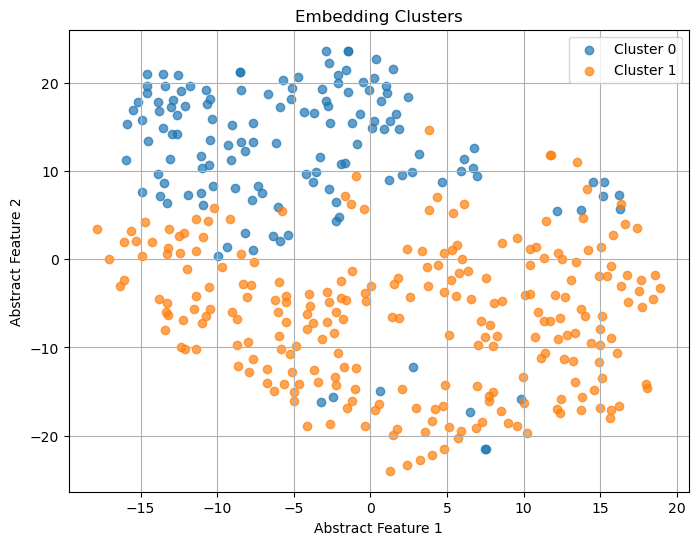

In [12]:
x2, y2 = visualize_embeddings_unsupervised(model, dataloader, n_clusters=2)

In [1]:
import cv2
import os
from tqdm import tqdm

# Paths
messidor_dir = './messidor'
dump_path = './rot_output'
os.makedirs(dump_path, exist_ok=True)

# Rotation angles
rotation_angles = [90]

def rotate_image(img, angle):
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

# Rotate and save images
for filename in tqdm(os.listdir(messidor_dir), desc="Applying rotation"):
    if not filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
        continue

    img_path = os.path.join(messidor_dir, filename)
    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️ Could not read image: {filename}")
        continue

    base_name = os.path.splitext(filename)[0]
    
    for angle in rotation_angles:
        rotated = rotate_image(img, angle)
        final_img_path = os.path.join(dump_path, f"{base_name}_rot{angle}.jpg")
        cv2.imwrite(final_img_path, rotated)
        print(f"✅ Saved to: {final_img_path}")


Applying rotation:   3%|█▉                                                            | 12/383 [00:00<00:06, 56.86it/s]

✅ Saved to: ./rot_output\c1_rot90.jpg
✅ Saved to: ./rot_output\c10_rot90.jpg
✅ Saved to: ./rot_output\c100_rot90.jpg
✅ Saved to: ./rot_output\c101_rot90.jpg
✅ Saved to: ./rot_output\c102_rot90.jpg
✅ Saved to: ./rot_output\c103_rot90.jpg
✅ Saved to: ./rot_output\c104_rot90.jpg
✅ Saved to: ./rot_output\c105_rot90.jpg
✅ Saved to: ./rot_output\c106_rot90.jpg
✅ Saved to: ./rot_output\c107_rot90.jpg
✅ Saved to: ./rot_output\c108_rot90.jpg
✅ Saved to: ./rot_output\c109_rot90.jpg


Applying rotation:   9%|█████▎                                                        | 33/383 [00:00<00:04, 86.20it/s]

✅ Saved to: ./rot_output\c11_rot90.jpg
✅ Saved to: ./rot_output\c110_rot90.jpg
✅ Saved to: ./rot_output\c111_rot90.jpg
✅ Saved to: ./rot_output\c112_rot90.jpg
✅ Saved to: ./rot_output\c113_rot90.jpg
✅ Saved to: ./rot_output\c114_rot90.jpg
✅ Saved to: ./rot_output\c115_rot90.jpg
✅ Saved to: ./rot_output\c116_rot90.jpg
✅ Saved to: ./rot_output\c117_rot90.jpg
✅ Saved to: ./rot_output\c118_rot90.jpg
✅ Saved to: ./rot_output\c119_rot90.jpg
✅ Saved to: ./rot_output\c12_rot90.jpg
✅ Saved to: ./rot_output\c120_rot90.jpg
✅ Saved to: ./rot_output\c121_rot90.jpg
✅ Saved to: ./rot_output\c122_rot90.jpg
✅ Saved to: ./rot_output\c123_rot90.jpg
✅ Saved to: ./rot_output\c124_rot90.jpg
✅ Saved to: ./rot_output\c125_rot90.jpg
✅ Saved to: ./rot_output\c126_rot90.jpg
✅ Saved to: ./rot_output\c127_rot90.jpg


Applying rotation:  11%|███████                                                       | 44/383 [00:00<00:03, 90.23it/s]

...

✅ Saved to: ./rot_output\c71_rot90.jpg
✅ Saved to: ./rot_output\c72_rot90.jpg
✅ Saved to: ./rot_output\c73_rot90.jpg
✅ Saved to: ./rot_output\c74_rot90.jpg
✅ Saved to: ./rot_output\c75_rot90.jpg
✅ Saved to: ./rot_output\c76_rot90.jpg
✅ Saved to: ./rot_output\c77_rot90.jpg
✅ Saved to: ./rot_output\c78_rot90.jpg
✅ Saved to: ./rot_output\c79_rot90.jpg
✅ Saved to: ./rot_output\c8_rot90.jpg
✅ Saved to: ./rot_output\c80_rot90.jpg
✅ Saved to: ./rot_output\c81_rot90.jpg
✅ Saved to: ./rot_output\c82_rot90.jpg
✅ Saved to: ./rot_output\c83_rot90.jpg


Applying rotation:  98%|███████████████████████████████████████████████████████████▌ | 374/383 [00:04<00:00, 75.50it/s]

✅ Saved to: ./rot_output\c84_rot90.jpg
✅ Saved to: ./rot_output\c85_rot90.jpg
✅ Saved to: ./rot_output\c86_rot90.jpg
✅ Saved to: ./rot_output\c87_rot90.jpg
✅ Saved to: ./rot_output\c88_rot90.jpg
✅ Saved to: ./rot_output\c89_rot90.jpg
✅ Saved to: ./rot_output\c9_rot90.jpg
✅ Saved to: ./rot_output\c90_rot90.jpg
✅ Saved to: ./rot_output\c91_rot90.jpg
✅ Saved to: ./rot_output\c92_rot90.jpg
✅ Saved to: ./rot_output\c93_rot90.jpg
✅ Saved to: ./rot_output\c94_rot90.jpg


Applying rotation: 100%|█████████████████████████████████████████████████████████████| 383/383 [00:04<00:00, 77.45it/s]

✅ Saved to: ./rot_output\c95_rot90.jpg
✅ Saved to: ./rot_output\c96_rot90.jpg
✅ Saved to: ./rot_output\c97_rot90.jpg
✅ Saved to: ./rot_output\c98_rot90.jpg
✅ Saved to: ./rot_output\c99_rot90.jpg


In [13]:

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from torch import nn, optim
from torchvision.models import resnet18
import numpy as np

# Custom Dataset for Triplet training
class TripletDataset(Dataset):
    def __init__(self, positive_dir, anchor_dir, negative_dir, transform=None):
        self.positive_dir = positive_dir
        self.anchor_dir = anchor_dir
        self.negative_dir = negative_dir
        self.transform = transform
        
        # Load the filenames of the images
        self.positive_images = [f for f in os.listdir(positive_dir) if f.endswith('_rot90.jpg')]
        self.anchor_images = [f.replace('_rot90', '') for f in self.positive_images]  # Matching anchor names
        self.negative_images = [f for f in os.listdir(negative_dir) if f.endswith('.png')]

    def __len__(self):
        return len(self.positive_images)

    def __getitem__(self, idx):
        positive_img_name = self.positive_images[idx]
        anchor_img_name = self.anchor_images[idx]

        # Construct full image paths
        positive_img_path = os.path.join(self.positive_dir, positive_img_name)
        anchor_img_path = os.path.join(self.anchor_dir, anchor_img_name)
        negative_img_name = np.random.choice(self.negative_images)
        negative_img_path = os.path.join(self.negative_dir, negative_img_name)

        # Open images using PIL
        positive_image = Image.open(positive_img_path)
        anchor_image = Image.open(anchor_img_path)
        negative_image = Image.open(negative_img_path)

        # Apply transformation if any
        if self.transform:
            positive_image = self.transform(positive_image)
            anchor_image = self.transform(anchor_image)
            negative_image = self.transform(negative_image)

        return anchor_image, positive_image, negative_image

# Transform to apply to images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [14]:
import os

# Initialize Dataset and DataLoader
positive_dir = './rot_output'
anchor_dir = './messidor'
negative_dir = './negative_images'

dataset = TripletDataset(positive_dir, anchor_dir, negative_dir, transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Define the embedding network (ResNet as an example)
class EmbeddingNet(nn.Module):
    def __init__(self):
        super(EmbeddingNet, self).__init__()
        self.resnet = resnet18(pretrained=True)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, 128)  # Output size 128 for embedding

    def forward(self, x):
        return self.resnet(x)

# Define Triplet Loss
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_distance = torch.norm(anchor - positive, p=2, dim=1)
        neg_distance = torch.norm(anchor - negative, p=2, dim=1)
        loss = torch.clamp(pos_distance - neg_distance + self.margin, min=0.0)
        return loss.mean()

In [15]:
# Model, loss, optimizer
model = EmbeddingNet().cuda()
loss_fn = TripletLoss(margin=1.0)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop
def train(model, dataloader, loss_fn, optimizer, n_epochs=10):
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0
        for batch_idx, (anchor, positive, negative) in enumerate(dataloader):
            # Move data to GPU
            anchor, positive, negative = anchor.cuda(), positive.cuda(), negative.cuda()

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            anchor_embedding = model(anchor)
            positive_embedding = model(positive)
            negative_embedding = model(negative)

            # Compute loss
            loss = loss_fn(anchor_embedding, positive_embedding, negative_embedding)

            # Backpropagation
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            if batch_idx % 10 == 0:
                print(f'Epoch [{epoch+1}/{n_epochs}], Step [{batch_idx+1}/{len(dataloader)}], Loss: {loss.item():.4f}')
        
        print(f'Epoch [{epoch+1}/{n_epochs}], Average Loss: {total_loss/len(dataloader):.4f}')

# Start training
train(model, dataloader, loss_fn, optimizer, n_epochs=25)

C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/25], Step [1/12], Loss: 0.1222
Epoch [1/25], Step [11/12], Loss: 0.0000
Epoch [1/25], Average Loss: 0.0522
Epoch [2/25], Step [1/12], Loss: 0.0111
Epoch [2/25], Step [11/12], Loss: 0.0000
Epoch [2/25], Average Loss: 0.0173
Epoch [3/25], Step [1/12], Loss: 0.0039
Epoch [3/25], Step [11/12], Loss: 0.0000
Epoch [3/25], Average Loss: 0.0074
Epoch [4/25], Step [1/12], Loss: 0.0000
Epoch [4/25], Step [11/12], Loss: 0.0000
Epoch [4/25], Average Loss: 0.0157
Epoch [5/25], Step [1/12], Loss: 0.0000
Epoch [5/25], Step [11/12], Loss: 0.0000
Epoch [5/25], Average Loss: 0.0054
Epoch [6/25], Step [1/12], Loss: 0.0000
Epoch [6/25], Step [11/12], Loss: 0.0054
Epoch [6/25], Average Loss: 0.0057
Epoch [7/25], Step [1/12], Loss: 0.0000
Epoch [7/25], Step [11/12], Loss: 0.0160
Epoch [7/25], Average Loss: 0.0041
Epoch [8/25], Step [1/12], Loss: 0.0000
Epoch [8/25], Step [11/12], Loss: 0.0344
Epoch [8/25], Average Loss: 0.0057
Epoch [9/25], Step [1/12], Loss: 0.0203
Epoch [9/25], Step [11/12], Loss

Epoch [68/300], Average Loss: 0.0000
Epoch [69/300], Step [1/12], Loss: 0.0000
Epoch [69/300], Step [11/12], Loss: 0.0000
Epoch [69/300], Average Loss: 0.0073
Epoch [70/300], Step [1/12], Loss: 0.0000
Epoch [70/300], Step [11/12], Loss: 0.0000
Epoch [70/300], Average Loss: 0.0043
Epoch [71/300], Step [1/12], Loss: 0.0000
Epoch [71/300], Step [11/12], Loss: 0.0000
Epoch [71/300], Average Loss: 0.0011
Epoch [72/300], Step [1/12], Loss: 0.0129
Epoch [72/300], Step [11/12], Loss: 0.0000
Epoch [72/300], Average Loss: 0.0011
Epoch [73/300], Step [1/12], Loss: 0.0000
Epoch [73/300], Step [11/12], Loss: 0.0000
Epoch [73/300], Average Loss: 0.0000
Epoch [74/300], Step [1/12], Loss: 0.0000
Epoch [74/300], Step [11/12], Loss: 0.0000
Epoch [74/300], Average Loss: 0.0000
Epoch [75/300], Step [1/12], Loss: 0.0000
Epoch [75/300], Step [11/12], Loss: 0.0000
Epoch [75/300], Average Loss: 0.0000
Epoch [76/300], Step [1/12], Loss: 0.0000
Epoch [76/300], Step [11/12], Loss: 0.0000
Epoch [76/300], Average 

Epoch [135/300], Step [1/12], Loss: 0.0000
Epoch [135/300], Step [11/12], Loss: 0.0000
Epoch [135/300], Average Loss: 0.0013
Epoch [136/300], Step [1/12], Loss: 0.0000
Epoch [136/300], Step [11/12], Loss: 0.0000
Epoch [136/300], Average Loss: 0.0040
Epoch [137/300], Step [1/12], Loss: 0.0000
Epoch [137/300], Step [11/12], Loss: 0.0000
Epoch [137/300], Average Loss: 0.0054
Epoch [138/300], Step [1/12], Loss: 0.0000
Epoch [138/300], Step [11/12], Loss: 0.0000
Epoch [138/300], Average Loss: 0.0006
Epoch [139/300], Step [1/12], Loss: 0.0000
Epoch [139/300], Step [11/12], Loss: 0.0000
Epoch [139/300], Average Loss: 0.0003
Epoch [140/300], Step [1/12], Loss: 0.0000
Epoch [140/300], Step [11/12], Loss: 0.0000
Epoch [140/300], Average Loss: 0.0024
Epoch [141/300], Step [1/12], Loss: 0.0000
Epoch [141/300], Step [11/12], Loss: 0.0000
Epoch [141/300], Average Loss: 0.0000
Epoch [142/300], Step [1/12], Loss: 0.0000
Epoch [142/300], Step [11/12], Loss: 0.0000
Epoch [142/300], Average Loss: 0.0000


Epoch [200/300], Average Loss: 0.0000
Epoch [201/300], Step [1/12], Loss: 0.0000
Epoch [201/300], Step [11/12], Loss: 0.0000
Epoch [201/300], Average Loss: 0.0015
Epoch [202/300], Step [1/12], Loss: 0.0000
Epoch [202/300], Step [11/12], Loss: 0.0000
Epoch [202/300], Average Loss: 0.0000
Epoch [203/300], Step [1/12], Loss: 0.0000
Epoch [203/300], Step [11/12], Loss: 0.0000
Epoch [203/300], Average Loss: 0.0000
Epoch [204/300], Step [1/12], Loss: 0.0000
Epoch [204/300], Step [11/12], Loss: 0.0000
Epoch [204/300], Average Loss: 0.0006
Epoch [205/300], Step [1/12], Loss: 0.0000
Epoch [205/300], Step [11/12], Loss: 0.0502
Epoch [205/300], Average Loss: 0.0043
Epoch [206/300], Step [1/12], Loss: 0.0000
Epoch [206/300], Step [11/12], Loss: 0.0000
Epoch [206/300], Average Loss: 0.0000
Epoch [207/300], Step [1/12], Loss: 0.0000
Epoch [207/300], Step [11/12], Loss: 0.0000
Epoch [207/300], Average Loss: 0.0022
Epoch [208/300], Step [1/12], Loss: 0.0000
Epoch [208/300], Step [11/12], Loss: 0.0000


Epoch [266/300], Step [11/12], Loss: 0.0000
Epoch [266/300], Average Loss: 0.0000
Epoch [267/300], Step [1/12], Loss: 0.0000
Epoch [267/300], Step [11/12], Loss: 0.0093
Epoch [267/300], Average Loss: 0.0008
Epoch [268/300], Step [1/12], Loss: 0.0000
Epoch [268/300], Step [11/12], Loss: 0.0000
Epoch [268/300], Average Loss: 0.0000
Epoch [269/300], Step [1/12], Loss: 0.0000
Epoch [269/300], Step [11/12], Loss: 0.0000
Epoch [269/300], Average Loss: 0.0008
Epoch [270/300], Step [1/12], Loss: 0.0000
Epoch [270/300], Step [11/12], Loss: 0.0000
Epoch [270/300], Average Loss: 0.0000
Epoch [271/300], Step [1/12], Loss: 0.0000
Epoch [271/300], Step [11/12], Loss: 0.0011
Epoch [271/300], Average Loss: 0.0020
Epoch [272/300], Step [1/12], Loss: 0.0000
Epoch [272/300], Step [11/12], Loss: 0.0000
Epoch [272/300], Average Loss: 0.0000
Epoch [273/300], Step [1/12], Loss: 0.0000
Epoch [273/300], Step [11/12], Loss: 0.0000
Epoch [273/300], Average Loss: 0.0020
Epoch [274/300], Step [1/12], Loss: 0.0000


In [16]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def visualize_embeddings_unsupervised(model, dataloader, n_clusters=2, use_tsne=True):
    model.eval()
    embeddings = []

    with torch.no_grad():
        for anchor, _, _ in dataloader:
            anchor = anchor.cuda()
            output = model(anchor)
            embeddings.append(output.cpu())

    embeddings = torch.cat(embeddings, dim=0).numpy()

    # Clustering with KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Dimensionality Reduction
    if use_tsne:
        reducer = TSNE(n_components=2, random_state=42)
    else:
        reducer = PCA(n_components=2)
    
    reduced_embeddings = reducer.fit_transform(embeddings)

    # Plotting
    plt.figure(figsize=(8, 6))
    for label in range(n_clusters):
        idxs = cluster_labels == label
        plt.scatter(reduced_embeddings[idxs, 0], reduced_embeddings[idxs, 1],
                    label=f'Cluster {label}', alpha=0.7)

    plt.title('Embedding Clusters')
    plt.xlabel('Abstract Feature 1')
    plt.ylabel('Abstract Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return reduced_embeddings, cluster_labels


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


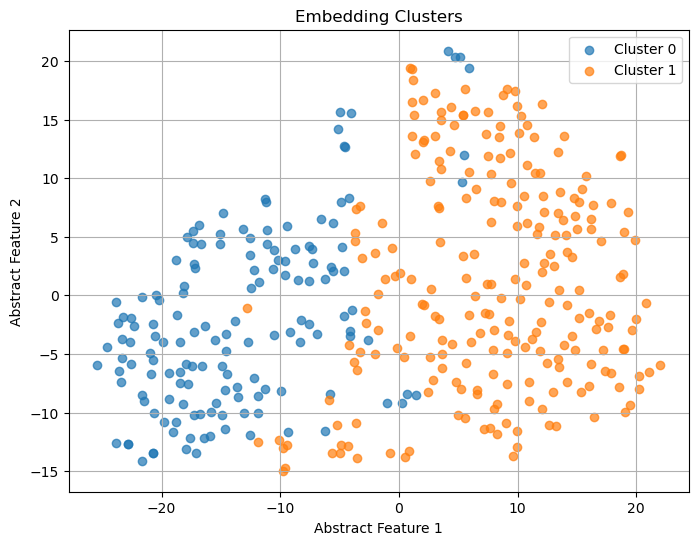

In [17]:
x3, y3 = visualize_embeddings_unsupervised(model, dataloader, n_clusters=2)

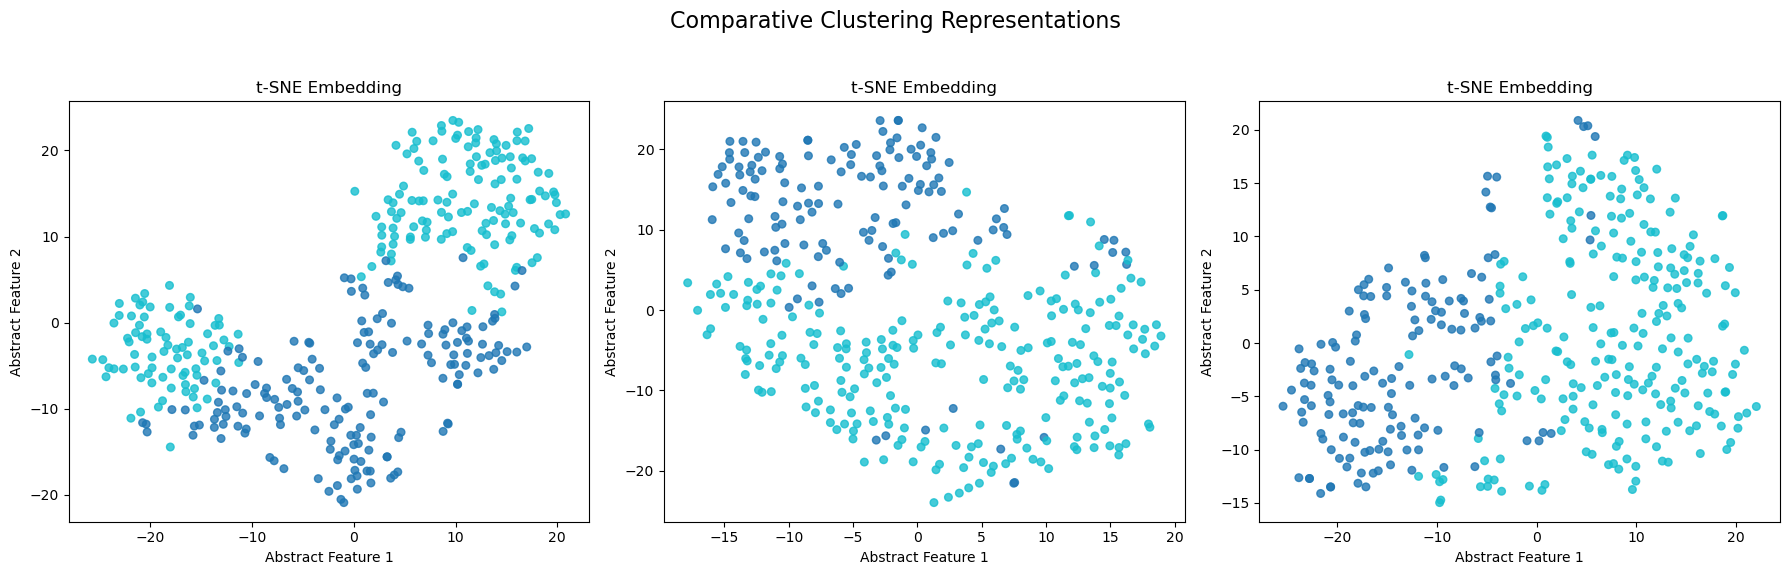

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets = [
    (x1, y1, "t-SNE Embedding"),
    (x2, y2, "t-SNE Embedding"),
    (x3, y3, "t-SNE Embedding")  # or any custom representation
]

for ax, (X, y, title) in zip(axes, datasets):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', s=30, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Abstract Feature 1")
    ax.set_ylabel("Abstract Feature 2")

fig.suptitle("Comparative Clustering Representations", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


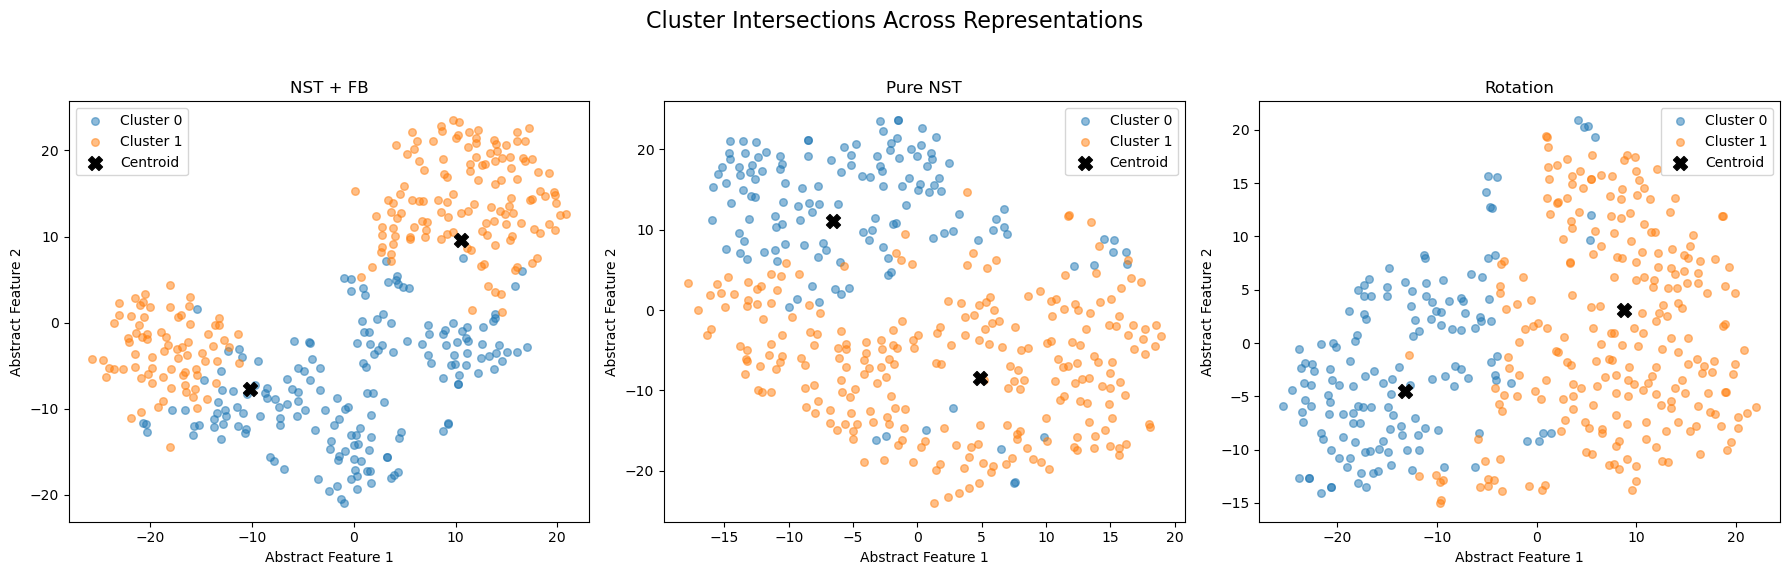

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets = [
    (x1, y1, "NST + FB"),
    (x2, y2, "Pure NST"),
    (x3, y3, "Rotation")
]

colors = ['#1f77b4', '#ff7f0e']  # Color for Cluster 0 and Cluster 1

for ax, (X, y, title) in zip(axes, datasets):
    for cluster_id in [0, 1]:
        cluster_points = X[y == cluster_id]
        ax.scatter(
            cluster_points[:, 0], cluster_points[:, 1],
            s=30,
            alpha=0.5,  # transparency to see overlapping areas
            color=colors[cluster_id],
            label=f"Cluster {cluster_id}"
        )
    
    # Optional: Add centroids to show separation
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=2, random_state=42).fit(X)
    centers = kmeans.cluster_centers_
    ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=100, label='Centroid')

    ax.set_title(title)
    ax.set_xlabel("Abstract Feature 1")
    ax.set_ylabel("Abstract Feature 2")
    ax.legend()

fig.suptitle("Cluster Intersections Across Representations", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


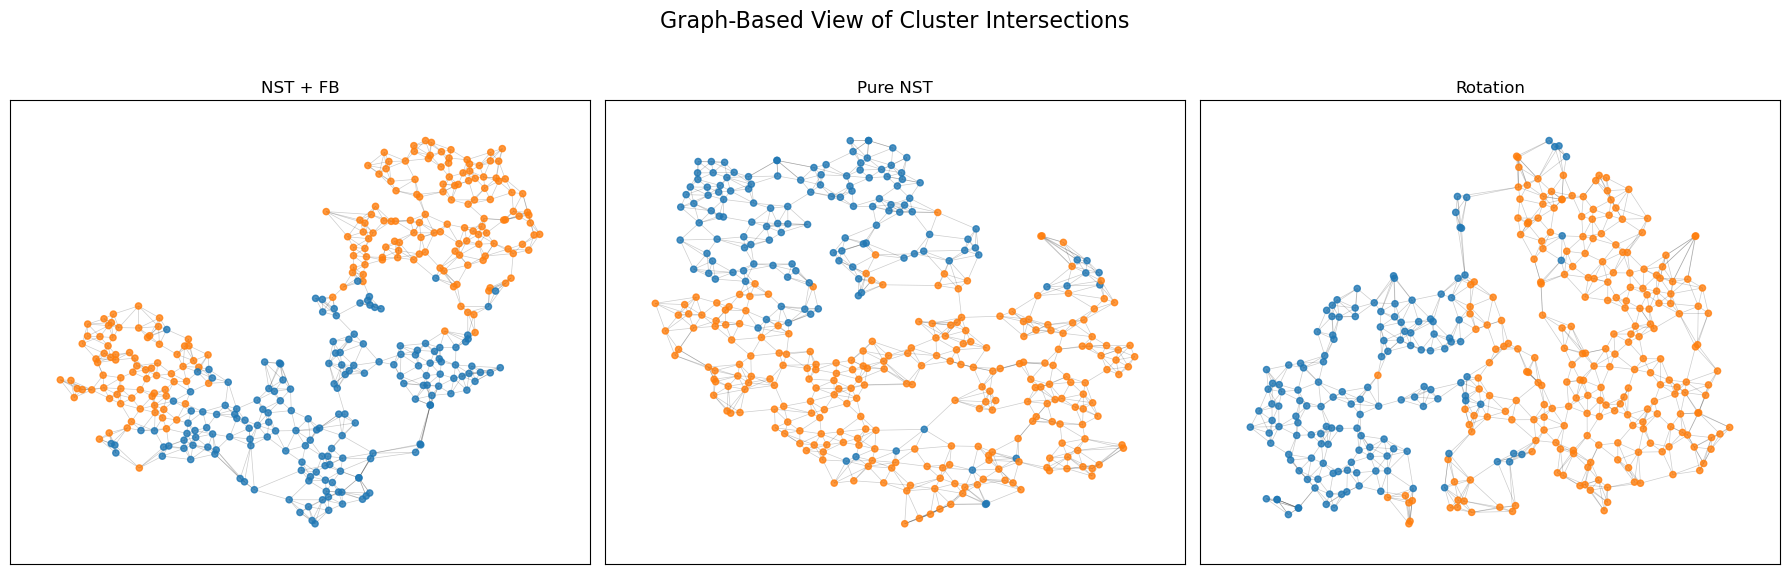

In [20]:
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.neighbors import kneighbors_graph

def plot_cluster_graph(X, labels, title, ax, k=5):
    # Build k-nearest neighbor graph
    knn_graph = kneighbors_graph(X, k, mode='connectivity', include_self=False)
    G = nx.Graph(knn_graph)

    # Map positions for networkx plotting
    pos = {i: (X[i, 0], X[i, 1]) for i in range(len(X))}

    # Draw edges
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, width=0.5)

    # Draw nodes with cluster coloring
    node_colors = ['#1f77b4' if label == 0 else '#ff7f0e' for label in labels]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, ax=ax, node_size=20, alpha=0.8)

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

# Plot all 3 cluster graphs
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_cluster_graph(x1, y1, "NST + FB", axes[0])
plot_cluster_graph(x2, y2, "Pure NST", axes[1])
plot_cluster_graph(x3, y3, "Rotation", axes[2])

plt.suptitle("Graph-Based View of Cluster Intersections", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


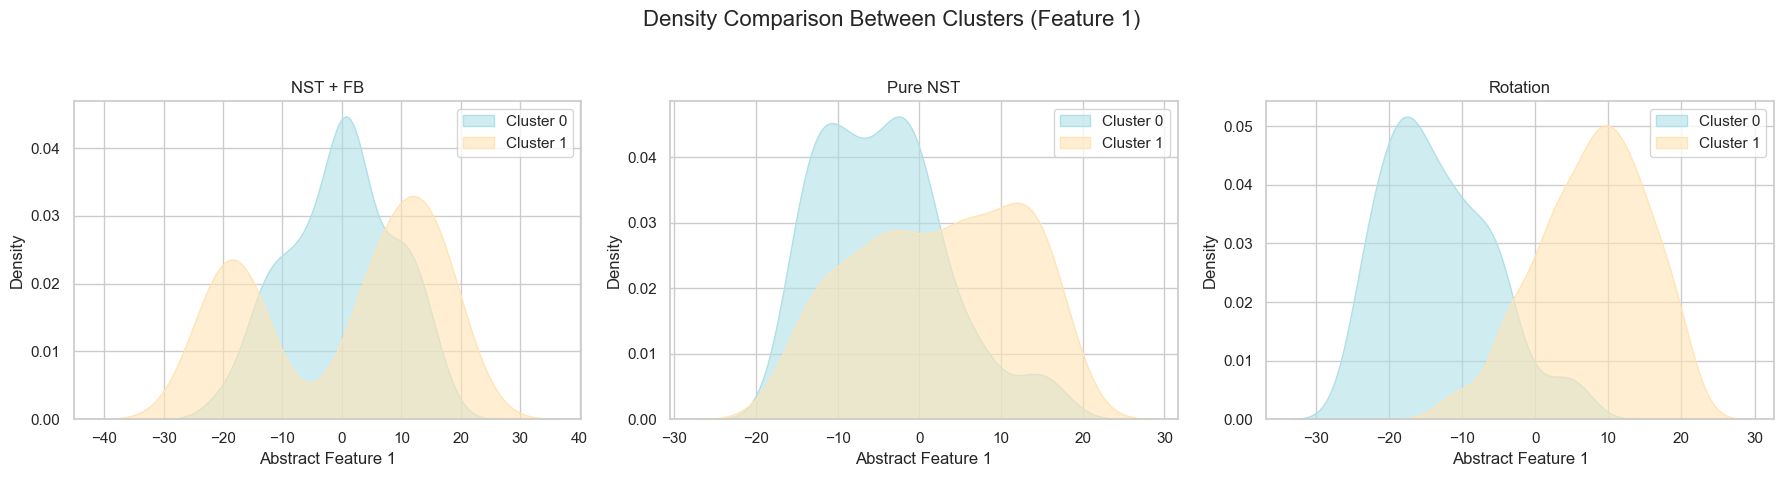

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

def plot_density(ax, X, y, title):
    # KDE for Abstract Feature 1
    sns.kdeplot(X[y == 0][:, 0], label="Cluster 0", fill=True, ax=ax, color='#B0E0E6', alpha=0.6)
    sns.kdeplot(X[y == 1][:, 0], label="Cluster 1", fill=True, ax=ax, color='#FFE4B5', alpha=0.6)

    ax.set_title(title)
    ax.set_xlabel("Abstract Feature 1")
    ax.set_ylabel("Density")
    ax.legend()

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_density(axes[0], x1, y1, "NST + FB")
plot_density(axes[1], x2, y2, "Pure NST")
plot_density(axes[2], x3, y3, "Rotation")

fig.suptitle("Density Comparison Between Clusters (Feature 1)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [22]:
from sklearn.metrics import silhouette_score

# Dataset 1: NST + FB
score1 = silhouette_score(x1, y1)
print(f"Silhouette Score for NST + FB: {score1:.4f}")

# Dataset 2: Pure NST
score2 = silhouette_score(x2, y2)
print(f"Silhouette Score for Pure NST: {score2:.4f}")

# Dataset 3: Rotation
score3 = silhouette_score(x3, y3)
print(f"Silhouette Score for Rotation: {score3:.4f}")


Silhouette Score for NST + FB: 0.2438
Silhouette Score for Pure NST: 0.3391
Silhouette Score for Rotation: 0.3967


In [11]:
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class TripletDataset(Dataset):
    def __init__(self, positive_dir, anchor_dir, negative_dir, transform=None, neg_seed=42):
        self.positive_dir = positive_dir
        self.anchor_dir = anchor_dir
        self.negative_dir = negative_dir
        self.transform = transform

        # Normalize paths for Windows compatibility
        self.positive_dir = os.path.normpath(positive_dir)
        self.anchor_dir = os.path.normpath(anchor_dir)
        self.negative_dir = os.path.normpath(negative_dir)

        # Validate directories
        for dir_path, name in [(positive_dir, 'positive'), 
                              (anchor_dir, 'anchor'),
                              (negative_dir, 'negative')]:
            if not os.path.exists(dir_path):
                raise FileNotFoundError(f"{name} directory not found: {dir_path}")

        # Suffix mapping with path component checking
        suffix_mapping = {
            'rot_output': '_rot90.jpg',
            'concatenated': '_concat.jpg',
            'nst_output': '_nst.jpg',
            'blended': '_blended.jpg'
        }

        # Find matching suffix
        suffix = None
        for key in suffix_mapping:
            if key in self.positive_dir.split(os.sep):
                suffix = suffix_mapping[key]
                break

        if suffix is None:
            raise ValueError(f"Could not determine suffix for directory: {positive_dir}")

        # Load filenames with verification
        self.positive_images = []
        self.anchor_images = []

        for f in sorted(os.listdir(positive_dir)):
            if f.endswith(suffix):
                anchor_name = f.replace(suffix, '.jpg')
                pos_path = os.path.join(positive_dir, f)
                anc_path = os.path.join(anchor_dir, anchor_name)

                try:
                    with Image.open(pos_path) as img:
                        img.verify()
                    with Image.open(anc_path) as img:
                        img.verify()

                    self.positive_images.append(f)
                    self.anchor_images.append(anchor_name)
                except (IOError, OSError) as e:
                    print(f"Skipping corrupt pair: {f} - Error: {e}")

        # Load negative images with verification
        self.negative_images = []
        for f in sorted(os.listdir(negative_dir)):
            if f.endswith('.png'):
                neg_path = os.path.join(negative_dir, f)
                try:
                    with Image.open(neg_path) as img:
                        img.verify()
                    self.negative_images.append(f)
                except (IOError, OSError) as e:
                    print(f"Skipping corrupt negative: {f} - Error: {e}")

        # Final validation
        if not self.positive_images:
            raise RuntimeError(f"No valid positive images found in {positive_dir}")
        if not self.negative_images:
            raise RuntimeError(f"No valid negative images found in {negative_dir}")

        # Pre-assign a fixed negative for each index using a seeded RNG.
        # This ensures every branch gets the SAME negative for the same idx,
        # making the triplet composition identical across augmentation techniques.
        rng = np.random.RandomState(neg_seed)
        self.neg_indices = rng.randint(0, len(self.negative_images), size=len(self.positive_images))

    def __len__(self):
        return len(self.positive_images)

    def __getitem__(self, idx):
        # Get image paths
        positive_img_path = os.path.join(self.positive_dir, self.positive_images[idx])
        anchor_img_path = os.path.join(self.anchor_dir, self.anchor_images[idx])
        # Use the pre-assigned negative instead of random selection
        negative_img_path = os.path.join(self.negative_dir, self.negative_images[self.neg_indices[idx]])
        
        try:
            anchor = Image.open(anchor_img_path).convert('RGB')
            positive = Image.open(positive_img_path).convert('RGB')
            negative = Image.open(negative_img_path).convert('RGB')
        except Exception as e:
            raise RuntimeError(f"Error loading images: {e}")

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Initialize datasets — all share the same neg_seed so negatives are identical per index
datasets = {
    "NST": TripletDataset('./nst_output', './messidor', './negative_images', transform, neg_seed=42),
    "Concat": TripletDataset('./result/concatenated', './messidor', './negative_images', transform, neg_seed=42),
    "Rotation": TripletDataset('./rot_output', './messidor', './negative_images', transform, neg_seed=42),
    "NST+FB": TripletDataset('./result/blended', './messidor', './negative_images', transform, neg_seed=42),
}

# DataLoaders are created inside the training loop with a fresh generator each time
# to ensure identical batch ordering across branches (see next cell).

In [12]:
from torchvision.models import resnet18
from torch import nn
import torch.nn.functional as F

class EmbeddingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = resnet18(pretrained=True)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, 128)  # Embedding size 128
        
    def forward(self, x):
        x = self.resnet(x)
        return F.normalize(x, p=2, dim=1)  # L2-normalized embeddings

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        loss = F.relu(pos_dist - neg_dist + self.margin)
        return loss.mean()

In [13]:
import torch
import copy
import random
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SEED = 42
TOTAL_EPOCHS = 125
CHECKPOINT_EVERY = 25  # Save model state at every 25 epochs

def seed_everything(seed):
    """Reset all RNGs so each branch starts from the same state."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def worker_init_fn(worker_id):
    """Ensure each DataLoader worker has a reproducible seed."""
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

def make_loader(dataset, batch_size=16, seed=42):
    """Create a DataLoader with a fresh seeded generator for deterministic shuffle order."""
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=g,
        worker_init_fn=worker_init_fn,
    )

def train_with_checkpoints(model, loader, optimizer, loss_fn, total_epochs, checkpoint_every):
    """Train once, save model snapshots at regular intervals."""
    model.train()
    checkpoints = {}
    
    for epoch in range(1, total_epochs + 1):
        total_loss = 0.0
        pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs}")
        
        for anchor, positive, negative in pbar:
            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)

            optimizer.zero_grad()
            anchor_emb = model(anchor)
            positive_emb = model(positive)
            negative_emb = model(negative)

            loss = loss_fn(anchor_emb, positive_emb, negative_emb)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())
        
        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch} - Avg Loss: {avg_loss:.4f}")
        
        # Save a deep copy of the model at each checkpoint
        if epoch % checkpoint_every == 0:
            checkpoints[epoch] = copy.deepcopy(model.state_dict())
            print(f"  >> Checkpoint saved at epoch {epoch}")
    
    return checkpoints

# Train all branches — single continuous run with checkpoints
all_checkpoints = {}  # {branch_name: {epoch: state_dict}}
models = {}

for name, ds in datasets.items():
    print(f"\n{'='*60}")
    print(f"=== Training {name} Model ({TOTAL_EPOCHS} epochs) ===")
    print(f"{'='*60}")
    
    # Reset all random state
    seed_everything(SEED)
    
    # Create DataLoader
    loader = make_loader(ds, batch_size=16, seed=SEED)
    
    # Build model with identical init weights
    model = EmbeddingNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    loss_fn = TripletLoss(margin=1.0)
    
    # Train once continuously, saving checkpoints
    checkpoints = train_with_checkpoints(model, loader, optimizer, loss_fn, TOTAL_EPOCHS, CHECKPOINT_EVERY)
    
    all_checkpoints[name] = checkpoints
    models[name] = model  # Final model (at TOTAL_EPOCHS)

print(f"\n{'='*60}")
print("Training complete! Checkpoints saved at epochs: " + 
      ", ".join(str(e) for e in range(CHECKPOINT_EVERY, TOTAL_EPOCHS+1, CHECKPOINT_EVERY)))
print(f"{'='*60}")

Using device: cuda

=== Training NST Model (125 epochs) ===


C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/125: 100%|█████████████████████████████████████████████████████████| 24/24 [00:24<00:00,  1.00s/it, loss=0.412]


Epoch 1 - Avg Loss: 0.5223


Epoch 2/125: 100%|█████████████████████████████████████████████████████████| 24/24 [00:23<00:00,  1.01it/s, loss=0.127]


Epoch 2 - Avg Loss: 0.1681


...

Epoch 123 - Avg Loss: 0.0026


Epoch 124/125: 100%|███████████████████████████████████████████████████████| 24/24 [00:23<00:00,  1.00it/s, loss=0.028]


Epoch 124 - Avg Loss: 0.0034


Epoch 125/125: 100%|███████████████████████████████████████████████████████████| 24/24 [00:23<00:00,  1.00it/s, loss=0]

Epoch 125 - Avg Loss: 0.0018
  >> Checkpoint saved at epoch 125

Training complete! Checkpoints saved at epochs: 25, 50, 75, 100, 125


In [14]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def get_embeddings(model, dataloader, device):
    """Extract embeddings from a trained model."""
    model.eval()
    embeddings = []
    with torch.no_grad():
        for anchor, _, _ in dataloader:
            anchor = anchor.to(device)
            output = model(anchor)
            embeddings.append(output.cpu())
    return torch.cat(embeddings, dim=0).numpy()

def evaluate_checkpoints(all_checkpoints, datasets, device, n_clusters=2):
    """Evaluate silhouette scores at every checkpoint for all branches."""
    
    # Score table: {branch_name: {epoch: score}}
    score_table = {}
    epoch_list = sorted(next(iter(all_checkpoints.values())).keys())
    
    for name, checkpoints in all_checkpoints.items():
        print(f"Evaluating {name}...")
        score_table[name] = {}
        loader = make_loader(datasets[name], batch_size=16, seed=SEED)
        
        for epoch, state_dict in sorted(checkpoints.items()):
            # Load checkpoint weights into a fresh model
            model = EmbeddingNet().to(device)
            model.load_state_dict(state_dict)
            
            # Get embeddings
            embeddings = get_embeddings(model, loader, device)
            
            # Cluster and score on 128-dim embeddings
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            labels = kmeans.fit_predict(embeddings)
            score = silhouette_score(embeddings, labels)
            
            score_table[name][epoch] = score
            print(f"  Epoch {epoch}: {score:.4f}")
    
    # ==========================================
    # LEARNING CURVE PLOT
    # ==========================================
    plt.figure(figsize=(10, 6))
    colors = {'NST': '#1f77b4', 'Concat': '#ff7f0e', 'Rotation': '#2ca02c', 'NST+FB': '#d62728'}
    markers = {'NST': 'o', 'Concat': 's', 'Rotation': '^', 'NST+FB': 'D'}
    
    for name, scores in score_table.items():
        epochs = sorted(scores.keys())
        values = [scores[e] for e in epochs]
        plt.plot(epochs, values, 
                marker=markers.get(name, 'o'), 
                color=colors.get(name, 'black'),
                linewidth=2, markersize=8, label=name)
    
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Silhouette Score (128-dim)", fontsize=12)
    plt.title("Learning Curve — Silhouette Score vs Training Epochs\n(Single continuous training run per branch)", fontsize=13)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(epoch_list)
    plt.tight_layout()
    plt.show()
    
    # ==========================================
    # SUMMARY TABLE
    # ==========================================
    print("\n" + "="*70)
    print(f"{'Method':<12}", end="")
    for e in epoch_list:
        print(f"{'Epoch '+str(e):>12}", end="")
    print(f"{'Best':>12}  {'Best Epoch':>12}")
    print("="*70)
    
    for name, scores in score_table.items():
        print(f"{name:<12}", end="")
        best_score = -1
        best_epoch = -1
        for e in epoch_list:
            s = scores[e]
            if s > best_score:
                best_score = s
                best_epoch = e
            print(f"{s:>12.4f}", end="")
        print(f"{best_score:>12.4f}  {'Epoch '+str(best_epoch):>12}")
    print("="*70)
    
    # ==========================================
    # t-SNE VISUALIZATION AT BEST EPOCH PER BRANCH
    # ==========================================
    n = len(score_table)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    
    for idx, (name, scores) in enumerate(score_table.items()):
        best_epoch = max(scores, key=scores.get)
        best_score = scores[best_epoch]
        
        # Load best checkpoint
        model = EmbeddingNet().to(device)
        model.load_state_dict(all_checkpoints[name][best_epoch])
        loader = make_loader(datasets[name], batch_size=16, seed=SEED)
        embeddings = get_embeddings(model, loader, device)
        
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embeddings)
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        reduced = tsne.fit_transform(embeddings)
        
        ax = axes[idx] if n > 1 else axes
        for label in range(n_clusters):
            mask = labels == label
            ax.scatter(reduced[mask, 0], reduced[mask, 1],
                      label=f'Cluster {label}', alpha=0.7, s=30)
        ax.set_title(f"{name} (Best: Epoch {best_epoch})\nSilhouette: {best_score:.4f}")
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.legend()
        ax.grid(True)
    
    plt.suptitle("t-SNE Visualization at Best Epoch per Augmentation", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return score_table

Evaluating NST...


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 25: 0.1943


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 50: 0.2201


...

  Epoch 75: 0.1457


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 100: 0.1470


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


  Epoch 125: 0.1573


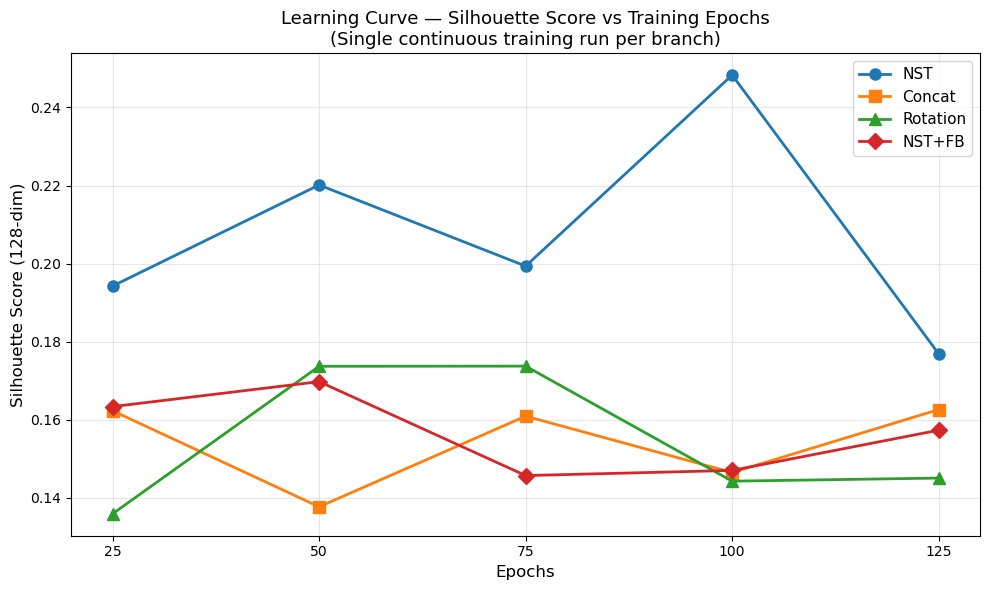


Method          Epoch 25    Epoch 50    Epoch 75   Epoch 100   Epoch 125        Best    Best Epoch
NST               0.1943      0.2201      0.1994      0.2483      0.1769      0.2483     Epoch 100
Concat            0.1623      0.1377      0.1609      0.1465      0.1626      0.1626     Epoch 125
Rotation          0.1359      0.1737      0.1737      0.1443      0.1451      0.1737      Epoch 75
NST+FB            0.1634      0.1698      0.1457      0.1470      0.1573      0.1698      Epoch 50


C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarnin

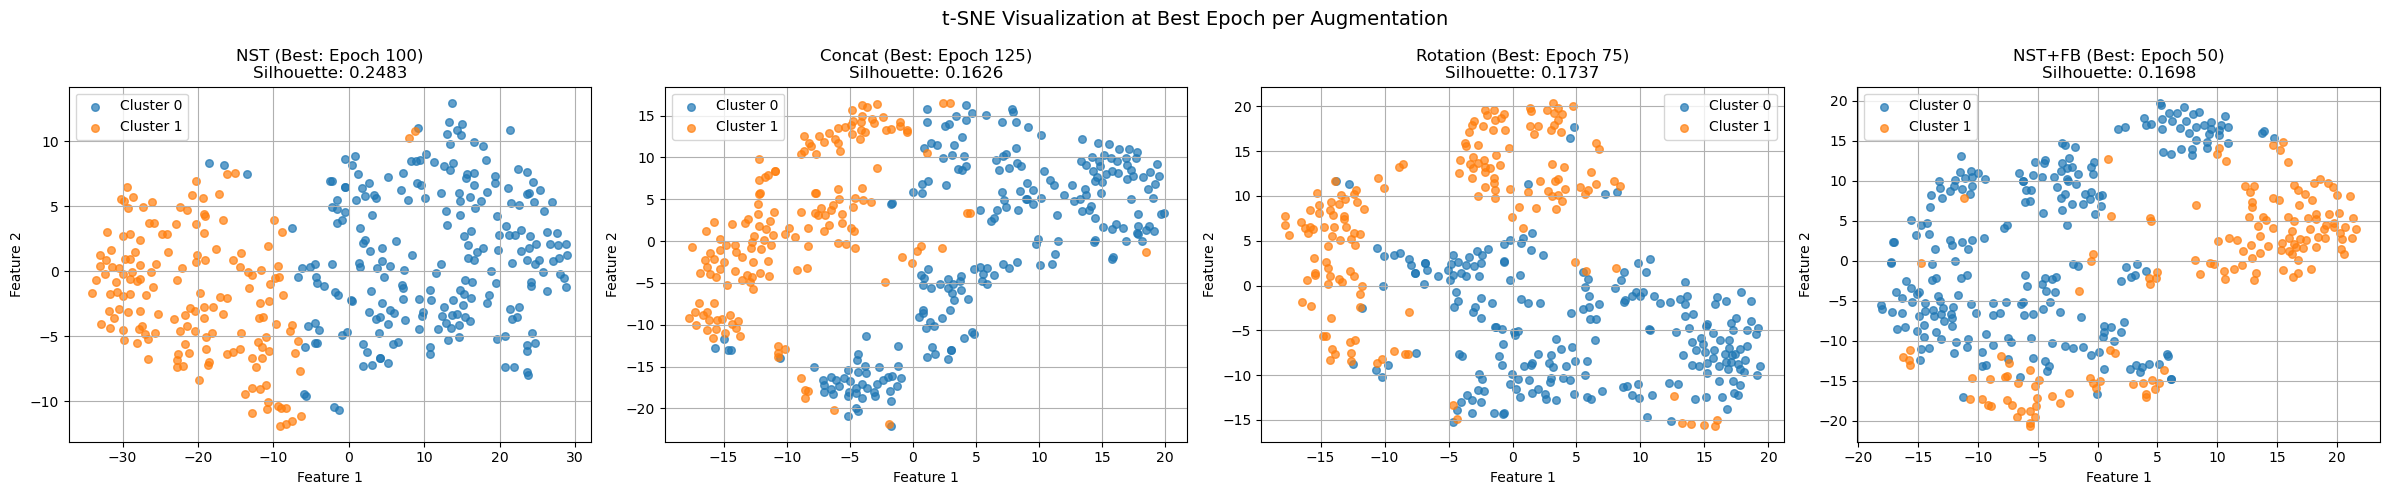

In [15]:
# Evaluate all checkpoints and plot learning curves
score_table = evaluate_checkpoints(all_checkpoints, datasets, device, n_clusters=2)

In [16]:
# Print silhouette scores from the results (already computed above)
for name, r in results.items():
    print(f"Silhouette Score for {name}: {r['score']:.4f}")

Silhouette Score for NST: 0.2385
Silhouette Score for Concat: 0.1877
Silhouette Score for Rotation: 0.1404
Silhouette Score for NST+FB: 0.2020
